In [1]:
import pandas as pd

cemetery_data = pd.read_csv('../data/historic_nashville_city_cemetery_interments_1846-1979.csv')
cemetery_clean = pd.read_csv('../data/nashville_cemetery_cleaned.csv')
cemetery_clean.head()

,Volume,Name,Burial Month,Month No.,Burial Day,Burial Year,Sex,Race,Age,Residence,Cause of Death/Burial,Ave,Section/Lot,Remarks,Cause_Cleaned,Cause_Category
0,6B,"Bell, Nancy Ann",Aug,8.0,6.0,1979.0,F,W,10.0,NaN,NaN,Oak,"sec. 28 NW, lot 12",J. L. Hughes lot,Unknown,Unknown
1,6W,"Drake, Mary Edith Smith, Mrs.",May,5.0,19.0,1979.0,F,W,67.0,"Madison, Tenn",Cancer,"Locust, Boyd Lot",lot 10,"wife of Alex M. Drake, Madison Funeral Home Of...",Cancer,Cancer
2,6D,"Davis, Bessie",Sep,9.0,19.0,1979.0,F,W,90.0,Nashville,Old Age,Poplar,"McAllister, E25, lot 8",daughter of Helen Davis,Old Age,Old Age
3,6C,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,Nashville,NaN,sect.ion 9,15,Magnolia,Unknown,Unknown
4,6W,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,"Nashville, Tennessee",NaN,NaN,NaN,Malgnolia,Unknown,Unknown


In [ ]:
## Find burial by year to search for patterns in the data. Specifically looking for spikes. 
burials_by_year = cemetery_data['Burial Year'].value_counts().sort_index()

mean = burials_by_year.mean()
std = burials_by_year.std()

spikes = burials_by_year[burials_by_year > mean + 2 * std]
print(f"Mean burials/year: {mean:.0f}  |  Std dev: {std:.0f}  |  Threshold: {mean + 2*std:.0f}\n")
print("Spike years:")
print(spikes.sort_values(ascending=False))

Mean burials/year: 154  |  Std dev: 272  |  Threshold: 698

Spike years:
Burial Year
1864.0    1372
1865.0    1366
1866.0    1354
1863.0     836
1850.0     809
1849.0     745
Name: count, dtype: int64


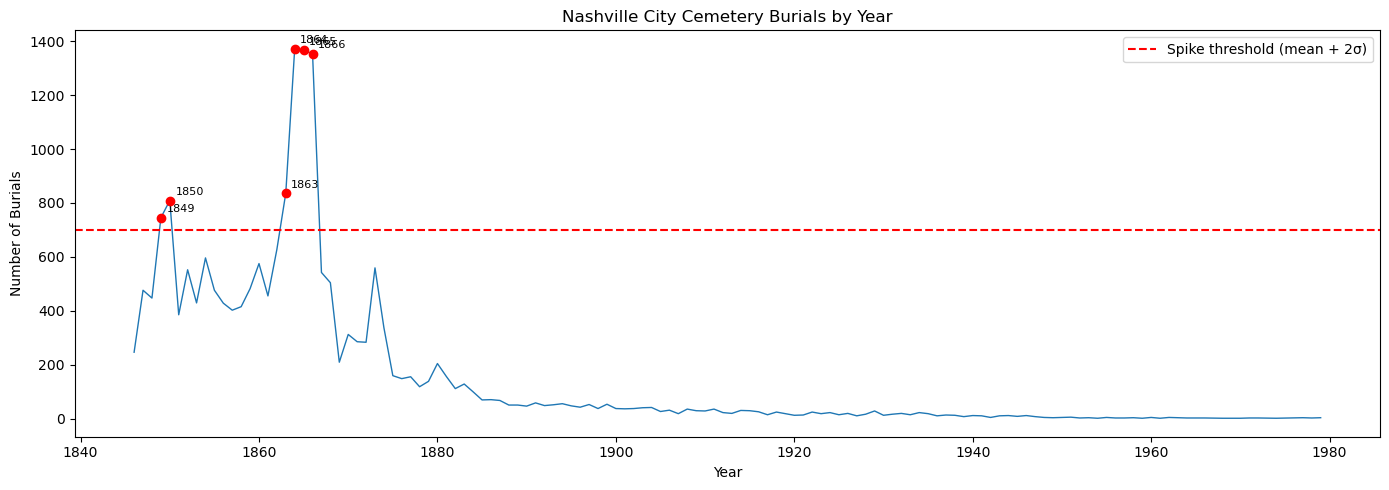

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(burials_by_year.index, burials_by_year.values, linewidth=1)
ax.axhline(mean + 2 * std, color='red', linestyle='--', label='Spike threshold (mean + 2σ)')
ax.scatter(spikes.index, spikes.values, color='red', zorder=5)

for year, count in spikes.items():
    ax.annotate(f'{int(year)}', xy=(year, count), xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_title('Nashville City Cemetery Burials by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Burials')
ax.legend()
plt.tight_layout()
plt.show()

Claude says tha the 1849-1850 spike is a result of a Cholera Epidemic. Nashville was hit particularly had and it spread rapidly though contaminated water supply. This combined with poor sanitation in Nashville's infrastructure led to many deaths.

The other spike in 1864 is a result of the Civil War and the Battle of Nashville (December 15-16, 1864). Many soldiers, both Union and Confederate were buried in the Nashville Cemetery.

Burial age coincides with both the 1849 cholera outbreak and the Civil War. Young children are particularly susceptible to dehydration and have a higher mortality rate from cholera. The 'unknown' ages around the Civil War make sense because many soldiers would have died without documentation. The second largest group was young adults which would account for the majority of soldiers.

In [5]:
## I want to create a new column name 'Decade' that groups the 'Burial Year' into decades. I want the output to be formatted 
## like '1840's' for the 1840s. To deal with NaN values, I will fill them with 'Unknown' before creating the decade column.
cemetery_clean['Burial Year'] = cemetery_clean['Burial Year'].fillna('Unknown')
cemetery_clean['Decade'] = cemetery_clean['Burial Year'].apply(lambda x: f"{int(x) // 10 * 10}'s" if x != 'Unknown' else 'Unknown')
cemetery_clean.head()

,Volume,Name,Burial Month,Month No.,Burial Day,Burial Year,Sex,Race,Age,Residence,Cause of Death/Burial,Ave,Section/Lot,Remarks,Cause_Cleaned,Cause_Category,Decade
0,6B,"Bell, Nancy Ann",Aug,8.0,6.0,1979.0,F,W,10.0,NaN,NaN,Oak,"sec. 28 NW, lot 12",J. L. Hughes lot,Unknown,Unknown,1970's
1,6W,"Drake, Mary Edith Smith, Mrs.",May,5.0,19.0,1979.0,F,W,67.0,"Madison, Tenn",Cancer,"Locust, Boyd Lot",lot 10,"wife of Alex M. Drake, Madison Funeral Home Of...",Cancer,Cancer,1970's
2,6D,"Davis, Bessie",Sep,9.0,19.0,1979.0,F,W,90.0,Nashville,Old Age,Poplar,"McAllister, E25, lot 8",daughter of Helen Davis,Old Age,Old Age,1970's
3,6C,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,Nashville,NaN,sect.ion 9,15,Magnolia,Unknown,Unknown,1970's
4,6W,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,"Nashville, Tennessee",NaN,NaN,NaN,Malgnolia,Unknown,Unknown,1970's


In [6]:
## I want to create a new column named 'Age Group' that categorizes the 'Age' column into groups. 
## These will be the groups: 'Child' for ages 5 or less, 'Minor' for ages 6-17, 'Young Adult' for ages 18-30, 'Middle Aged' for 
## ages 31-50, and 'Older Adult' for ages older than 50. If there is and blank for age fill in the age group value as unknown.
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 5:
        return 'Child'
    elif 6 <= age <= 17:
        return 'Minor'
    elif 18 <= age <= 30:
        return 'Young Adult'
    elif 31 <= age <= 50:
        return 'Middle Aged'
    else:
        return 'Older Adult'
cemetery_clean['Age Group'] = cemetery_clean['Age'].apply(categorize_age)
cemetery_clean.head()

,Volume,Name,Burial Month,Month No.,Burial Day,Burial Year,Sex,Race,Age,Residence,Cause of Death/Burial,Ave,Section/Lot,Remarks,Cause_Cleaned,Cause_Category,Decade,Age Group
0,6B,"Bell, Nancy Ann",Aug,8.0,6.0,1979.0,F,W,10.0,NaN,NaN,Oak,"sec. 28 NW, lot 12",J. L. Hughes lot,Unknown,Unknown,1970's,Minor
1,6W,"Drake, Mary Edith Smith, Mrs.",May,5.0,19.0,1979.0,F,W,67.0,"Madison, Tenn",Cancer,"Locust, Boyd Lot",lot 10,"wife of Alex M. Drake, Madison Funeral Home Of...",Cancer,Cancer,1970's,Older Adult
2,6D,"Davis, Bessie",Sep,9.0,19.0,1979.0,F,W,90.0,Nashville,Old Age,Poplar,"McAllister, E25, lot 8",daughter of Helen Davis,Old Age,Old Age,1970's,Older Adult
3,6C,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,Nashville,NaN,sect.ion 9,15,Magnolia,Unknown,Unknown,1970's,Older Adult
4,6W,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,"Nashville, Tennessee",NaN,NaN,NaN,Malgnolia,Unknown,Unknown,1970's,Older Adult


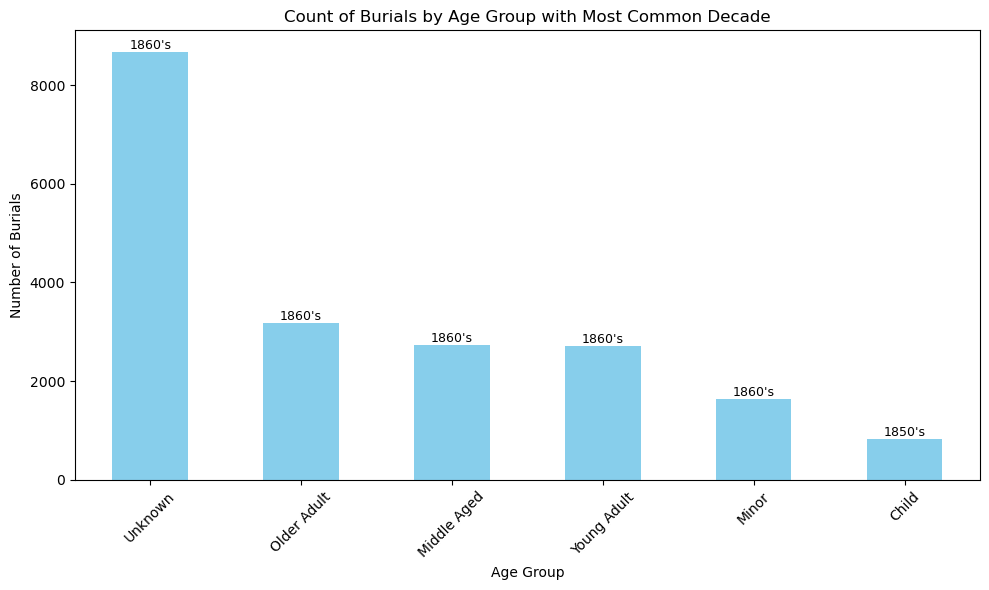

In [7]:
# I want to create a visualization that shows the count of burials and most common burial decade for each age group. 
age_group_counts = cemetery_clean['Age Group'].value_counts()
age_group_decades = cemetery_clean.groupby('Age Group')['Decade'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
fig, ax = plt.subplots(figsize=(10, 6))
age_group_counts.plot(kind='bar', ax=ax, color='skyblue')   
for i, (age_group, count) in enumerate(age_group_counts.items()):
    decade = age_group_decades[age_group]
    ax.text(i, count + 1, f'{decade}', ha='center', va='bottom', fontsize=9)    
ax.set_title('Count of Burials by Age Group with Most Common Decade')
ax.set_xlabel('Age Group')  
ax.set_ylabel('Number of Burials')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The large group of 'Unknown' ages is accoutned for by the Civil War and the numerous battlefield deaths. Those deaths were frequently not fully or properly documented, especially for Union troops. 

All age groups experience the most burial in the 1860s due to the Civil War and the following cholera outbreak. The only exception was "Child". Young children were more drastically impacted by the previous cholera outbreak in the 1850s.

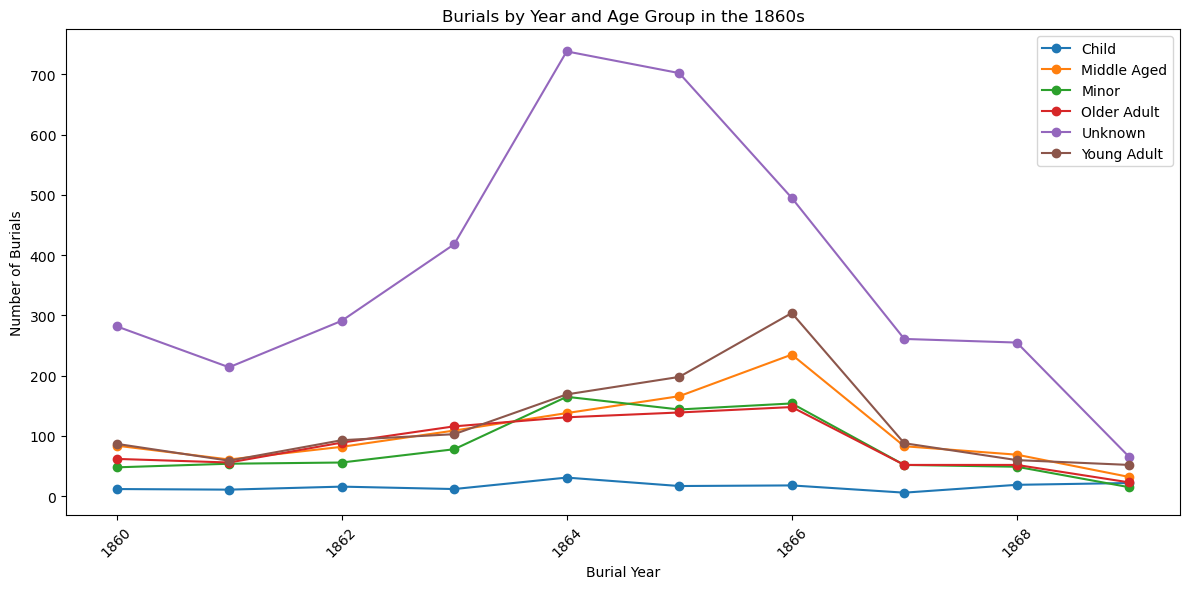

In [8]:
# I want to count the number of burials for each age group for every year in the 1860s decade.
# I want to visualize this data as a line plot with years on the x-axis and count of burials on the y-axis, 
# with separate lines for each age group.

decade_1860s = cemetery_clean[cemetery_clean['Decade'] == "1860's"]
burials_by_year_age_group = decade_1860s.groupby(['Burial Year', 'Age Group']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6)) 
for age_group in burials_by_year_age_group.columns:
    ax.plot(burials_by_year_age_group.index, burials_by_year_age_group[age_group], marker='o', label=age_group)
ax.set_title('Burials by Year and Age Group in the 1860s')
ax.set_xlabel('Burial Year')
ax.set_ylabel('Number of Burials')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  


Many dead soldiers from surrounding areas would have been sent to Nashville for burial. The combination of local deaths, bodies from nearby areas, and the soldiers from other parts of the country likely overloaded the capacity of the cemetery to properly document the majority of deaths. 

The peak of Young Adults after the war could be attributed to wounded soldiers in Nashville area hospitals who, in thier weakened state, were susceptible to cholera. 

Children noteably remain flat showing that they were not impacted by the war or the second cholera outbreak.

In [9]:
cemetery_clean.to_csv('../data/cemetery_powerbi.csv', index=False)
print("Exported to data/cemetery_powerbi.csv")

Exported to data/cemetery_powerbi.csv
